<a href="https://colab.research.google.com/github/shadinyri/bank_account_fraud_detection/blob/main/Data%20loading%20and%20EDA%20setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!git clone https://github.com/feedzai/bank-account-fraud.git
%cd bank-account-fraud

Cloning into 'bank-account-fraud'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 110 (delta 54), reused 65 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (110/110), 1.13 MiB | 23.62 MiB/s, done.
Resolving deltas: 100% (54/54), done.
/content/bank-account-fraud


In [4]:
!pip install pandas pyarrow lightgbm scikit-learn

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import glob
import pandas as pd

# ۱. تغییر پسوند جستجو به csv
data_paths = glob.glob("/content/drive/MyDrive/BAF_Project/archive/*.csv")

def read_dataset(path):
    # ۲. تغییر دستور به read_csv و تنظیم ستون اول به عنوان ایندکس
    return pd.read_csv(path)

def get_variant(path):
    return path.split("/")[-1].split(".")[0]

dataframes = {
    get_variant(path): read_dataset(path) for path in data_paths
}

# بررسی اینکه داده‌ها این بار به درستی بارگذاری شده‌اند
print(dataframes.keys())

dict_keys(['Base', 'Variant I', 'Variant II', 'Variant III', 'Variant IV', 'Variant V'])


In [10]:
# استخراج مجموعه داده پایه
df = dataframes['Base'].copy()

# ۱. تعریف متغیر حساس (افراد ۵۰ سال و بیشتر به عنوان گروه اقلیت)
# این متغیر نباید وارد مدل شود، اما برای محاسبه انصاف در مرحله بعد به آن نیاز داریم
sensitive_attr = (df['customer_age'] >= 50).astype(int)

# ۲. جداسازی ویژگی‌ها (X) و متغیر هدف (y)
# ستون ماه (month) را فعلاً نگه می‌داریم تا تفکیک زمانی انجام دهیم
X = df.drop(columns=['fraud_bool', 'customer_age'])
y = df['fraud_bool']

# ۳. کدگذاری متغیرهای دسته‌ای (Label Encoding)
# تبدیل متغیرهای متنی به کدهای عددی برای الگوریتم‌های یادگیری ماشین
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    X[col] = X[col].astype('category').cat.codes

# ۴. تفکیک زمانی (Temporal Split)
# بر اساس مستندات مقاله، ماه‌های ۰ تا ۵ برای آموزش و ۶ و ۷ برای استقرار (تست)
train_mask = X['month'] <= 5
test_mask = X['month'] > 5

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# جداسازی متغیر حساس مختص داده‌های تست برای ارزیابی نهایی
sensitive_test = sensitive_attr[test_mask]

# ۵. حذف ستون month
# مدل نباید مستقیماً روی شماره ماه آموزش ببیند تا بتواند در ماه‌های آینده (تعمیم‌پذیری) کار کند
X_train = X_train.drop(columns=['month'])
X_test = X_test.drop(columns=['month'])

print(f"training_data: {X_train.shape}")
print(f"test_data: {X_test.shape}")

training_data: (794989, 29)
test_data: (205011, 29)


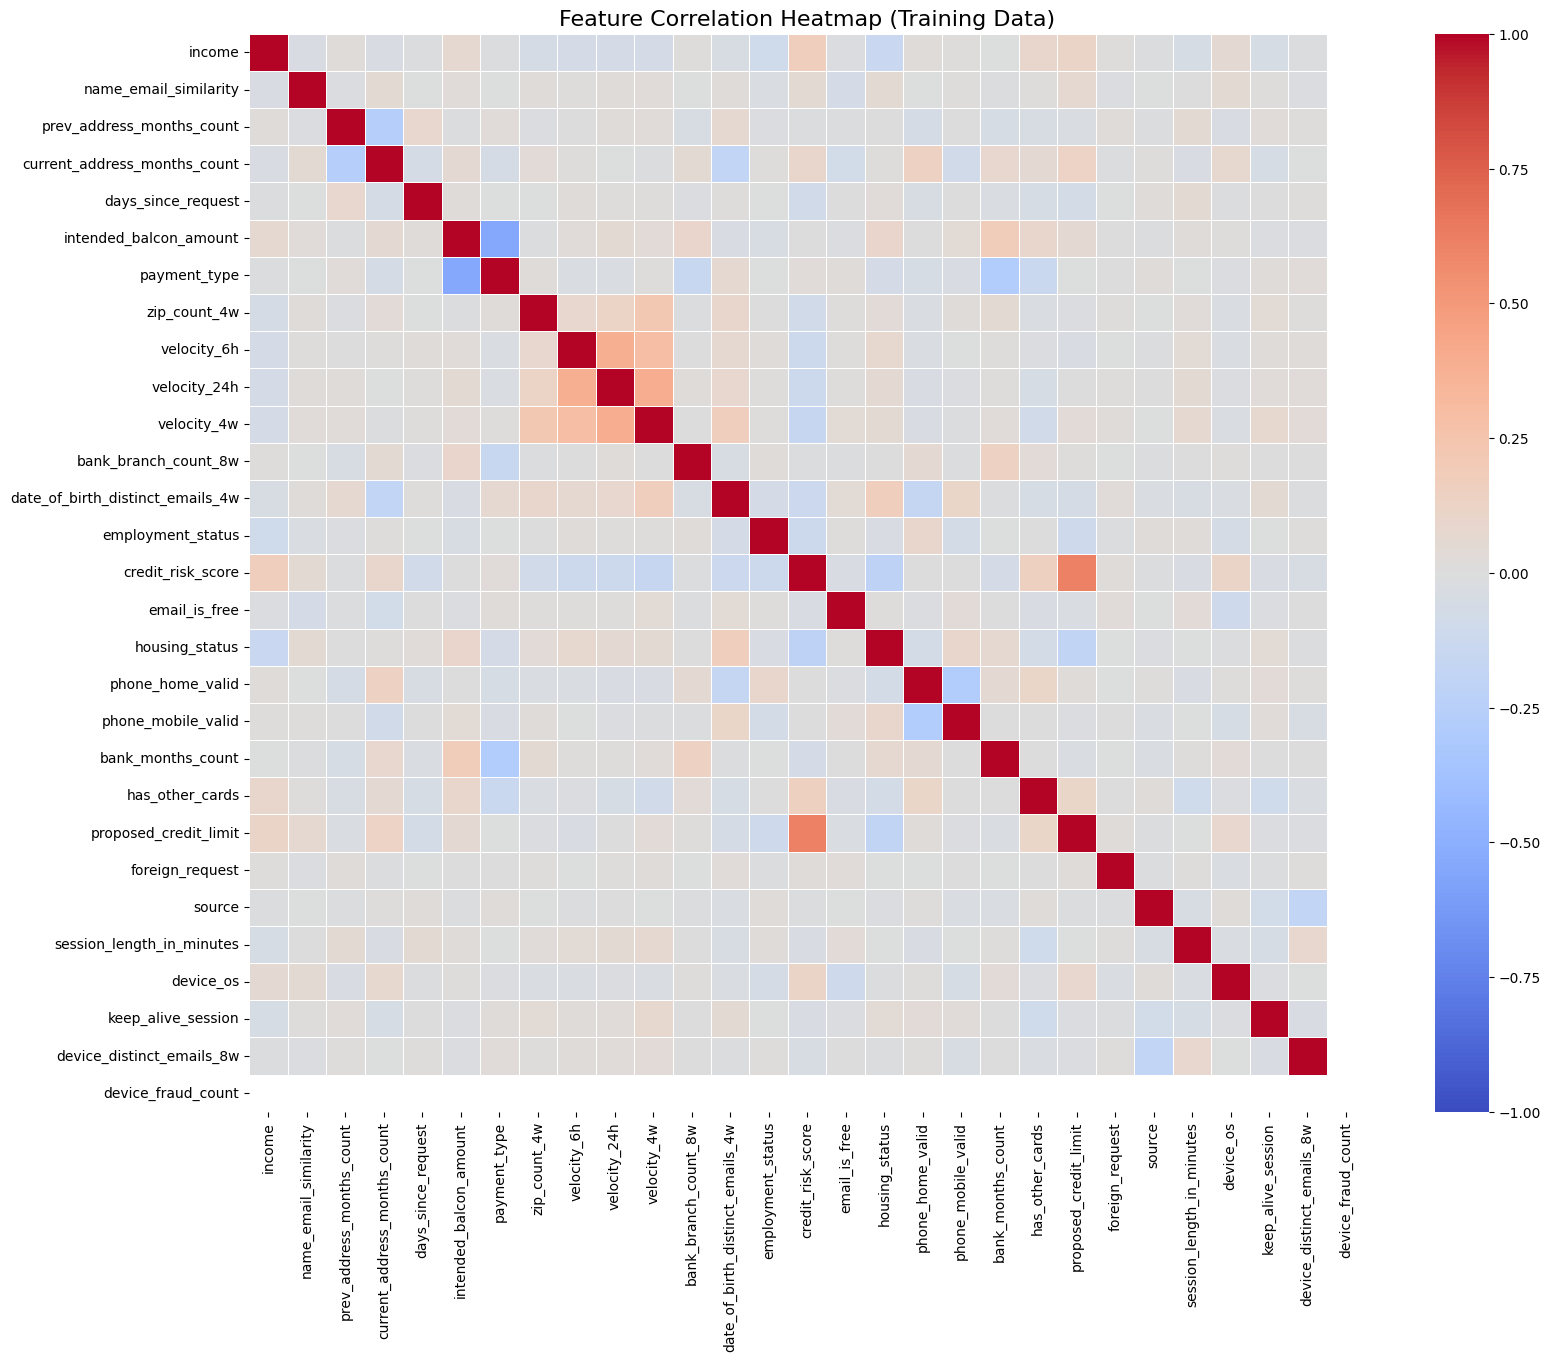

Highly correlated feature pairs (> 0.8):
No pair feature found with correlation magnitude higher than 0.8.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the Pearson correlation matrix for the training features
corr_matrix = X_train.corr()

# 2. Set up the matplotlib figure size to accommodate 29 features
plt.figure(figsize=(18, 14))

# 3. Create a heatmap using seaborn
# cmap='coolwarm': Blue for negative correlation, Red for positive
# annot=False: Hiding numbers inside boxes to prevent visual clutter
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title('Feature Correlation Heatmap (Training Data)', fontsize=16)
plt.show()

# 4. Identify highly correlated feature pairs (threshold > 0.8)
print("Highly correlated feature pairs (> 0.8):")
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            feature_1 = corr_matrix.columns[i]
            feature_2 = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j]
            print(f"- {feature_1} and {feature_2}: {corr_value:.4f}")
else:
    print(f"No pair feature found with correlation magnitude higher than 0.8.")

In [12]:
# 1. Calculate absolute correlation matrix (ignoring negative/positive direction for ranking)
corr_matrix = X_train.corr().abs()

# 2. Unstack the matrix into a 1D series of pairs
unstacked_corr = corr_matrix.unstack()

# 3. Filter out self-correlations (where value is 1.0) and drop duplicate pairs
pairs = unstacked_corr[unstacked_corr < 1].drop_duplicates()

# 4. Sort the pairs in descending order
sorted_pairs = pairs.sort_values(ascending=False)

# 5. Display the top 20 most correlated pairs
print("Top 20 Correlated Feature Pairs:")
print(sorted_pairs.head(20))

Top 20 Correlated Feature Pairs:
credit_risk_score                 proposed_credit_limit               0.612478
intended_balcon_amount            payment_type                        0.539710
velocity_24h                      velocity_4w                         0.396655
velocity_6h                       velocity_24h                        0.388247
                                  velocity_4w                         0.295824
payment_type                      bank_months_count                   0.286726
phone_home_valid                  phone_mobile_valid                  0.285308
prev_address_months_count         current_address_months_count        0.264155
zip_count_4w                      velocity_4w                         0.223727
credit_risk_score                 housing_status                      0.214148
housing_status                    proposed_credit_limit               0.190139
current_address_months_count      date_of_birth_distinct_emails_4w    0.186541
source             

In [16]:
# 1. Calculate the standard correlation matrix (without absolute yet)
corr_matrix = X_train.corr()

# 2. Unstack and remove self-correlations (1.0) and duplicates
unstacked_corr = corr_matrix.unstack()
pairs = unstacked_corr[unstacked_corr < 1.0].drop_duplicates()

# 3. Define the threshold for strong correlation
threshold = 0.5

# 4. Filter pairs where the ABSOLUTE correlation is greater than the threshold
# This captures both > 0.5 and < -0.5
strong_pairs = pairs[pairs.abs() > threshold]

# 5. Conditional output (if/else)
if strong_pairs.empty:
    print(f"No pair feature found with correlation magnitude higher than {threshold}.")
else:
    print(f"Highly correlated feature pairs (magnitude > {threshold}):")
    # Sort by absolute value to show the strongest relationships first
    print(strong_pairs.reindex(strong_pairs.abs().sort_values(ascending=False).index))

Highly correlated feature pairs (magnitude > 0.5):
credit_risk_score       proposed_credit_limit    0.612478
intended_balcon_amount  payment_type            -0.539710
dtype: float64
